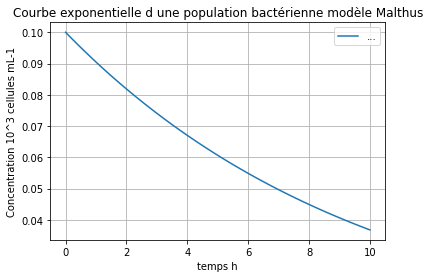

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# Paramètres de la simulation
rmax = -0.1 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)
# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('Courbe exponentielle d une population bactérienne modèle Malthus') # Titre du graphique
plt.plot(time, C, label='...') # Nom de la courbe
plt.xlabel('temps h') # Axe des X
plt.ylabel('Concentration 10^3 cellules mL-1') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()


La courbe observée est une courbe exponentionelle. La population augmente de plus en plus en fonction du temps. 

Dans ce modèle exponentionelle ; 
t double = ln(2)/ rmax 
                avec rmax = 0,2 
                ln(2)/0,2 = environ 3,5 
La population augmente environ toutes les 3,5h.
Pour r= 0,4 t=1,7h 
Pour r=0,1 t=6,9h
Pour r=0 la population reste constante
Pour r=-0,1 la population décroissant au cours du temps

En changeant le rmax on remarque que rmax est proportionelle à la concentration. 
On remarque qu'avec r = 0,4 la population augmente plus rapidement, le temps de doublement est plus court alors que pour r=0,1 la population augmente mais plus progressivement

Dans le modèle de Malthus les ressources sont infinis, l'environnement est constant. Pour le rendre plus réaliste il faudrait des ressources limitées pour faire variée le rmax. La variation de rmax conditionne la croissance de la population. 


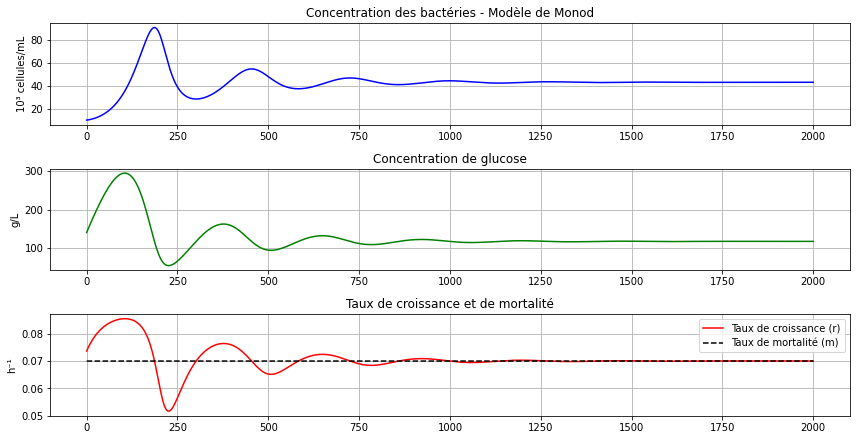

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]
# Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

Au début la croissance est rapide car beaucoup de glucose est disponible puis la croissance diminue, la population fini par diminuer.
La population s écroule car le glucose diminue progressivement, il est consommé par les bactéries. 
La mortalité devient supérieur à la croissance. 
Le facteur limitant est le glucose car c est la ressource nécessaire à la croissance des bactéries. 

La population atteint son maximum lorsque r=m et ici m= 0.07. Si r< m la mortalité est supérieur à la croissance de la population. Donc quand r=0.07 la mortalité et la croissance se compense. 

Pour déterminer graphiquement la valur de K on utilise : r = rmax/2 ici rmax = 0.10
        rmax/2 = 0.05 ce qui donne graphiquement une valeur de K = 50 g/L

Rmax représente le taux de croissance maximal des bactéries; 
    Si r augmente la croissance augmente rapidement mais le glucose est consommé rapidement. On observe une croissance très rapide puis une chute brutale. 
    Si r diminue la population se développe moins rapidement. 
    
M0 qui est la mortalité ;
    si elle augmente il y a davantage de bactéries qui meurent, la population atteint un maximum plus faible si m > r alors la population diminuent directement.
    si elle diminue alors les bactéries sont vivantes, si m< r alors la population augmente. 
    
K représente l'affinité pour le glucose; 
    si K augmente l'affinité pour le glucose est plus faible, la population augmente moins facilement 
    si K diminue on a une meilleure affinité pour le glucose, la population se maintient mieux. 

Pour maintenir la population dans le temps il faudrait un apport continue de glucose. 

Le glucose est continuellement apporté, la population peut donc survivre longtemps. Après des variations des courbes un équilibre apparaît. 
Au début il y a beaucoup de bactéries, on a une croissance exponentionelle donc forte consommation, le glucose chute puis le glucose remonte grâce à l'inflow les bactéries re augmentent. Cela crée des oscillations avant stabilisation où le taux de croissance = taux de mortalité. 







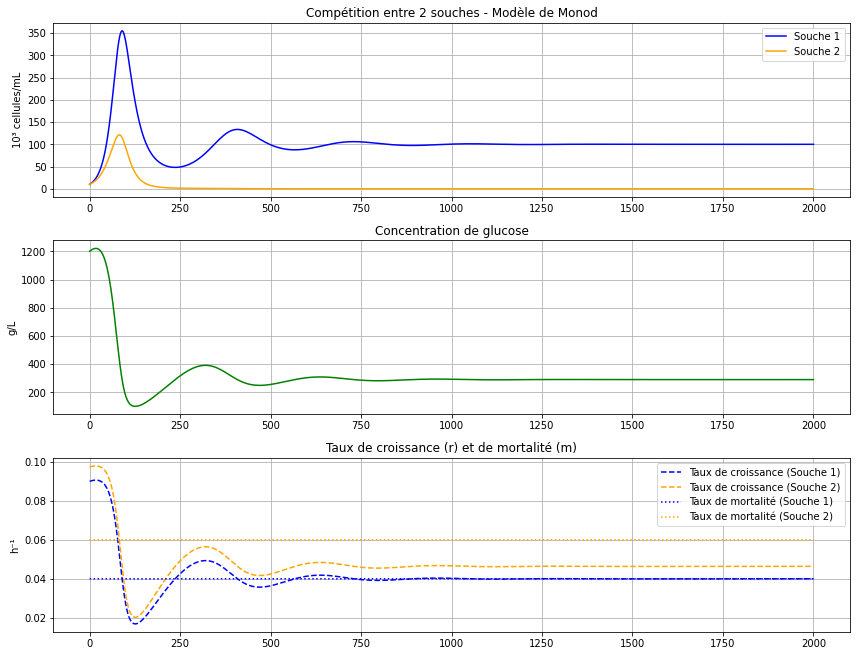

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.04      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

      # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Au début les 2 souches augmentent, les bactéries se divisent rapidement car le glucose est très élevé mais la souche 2 est dominante. Les 2 souches sont en compétition pour la même ressource : le glucose. 
Le glucose diminue à cause de la consommation des bactéries puis se stabilise. Un équilibre apparaît entre consommation des bactéries et apport de glucose. 
Au début les taux de croissance sont élevés puis ils diminuent progressivement lorsque le glucose devient limitant. 
La souche 2 conserve généralement un avantage. Et le taux de mortalité restent constants pendant toute la stimulation m = 0.06.

La souche 2 finit par dominer la population parce qu'elle présente une meilleure affinité pour le glucose. 
K2 = 650 < K1 = 800
K2< K1 
Elle peut donc croître efficacement même lorsque le glucose devient faible. La souche 1 est progressivement désavantagée et disparaît presque. 

Quand m1 diminue la mortalité de la souche 1 devient plus faible, elle survit mieux, elle peut comprenser son désavantage lié au glucose. 
En testant plusieurs valeurs à m1 = 0.04 la souche 1 devient dominante. Une mortalité plus faible peut compenser une moins bonne affinité pour le glucose. 

Cette stimulation montre la séléction naturelle. La souche la plus adaptée aux ressources disponibles finit par être sélectionnée. Il faut modifier un paramètre pour pouvoir modifier cette séléction.

Les 2 souches peuvent coexister si leurs paramètres sont proches, aucune n'a un avantage trop important et les ressources sont suffisamment disponible. 

Si rmax augmente la souche croit rapidement et a un avantage. 
Si K augmente la souche devient compétitive à faible concentration à contrario si K diminue elle est moins compétitive à même concentration. 



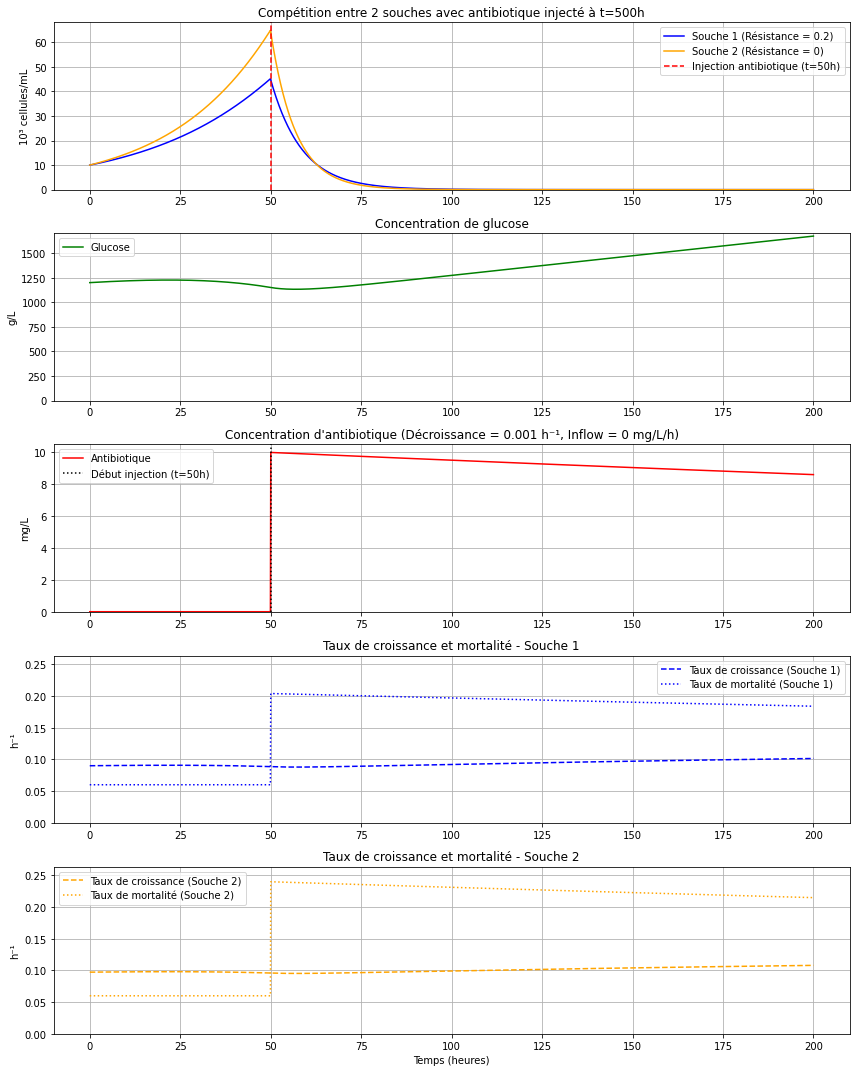

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.06        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.2  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.06        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 4      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.001    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)
    
      # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

On observe sur la courbe de la concentration en antibiotique que la concentration de cette antibiotique diminue à cause de sa dégradation passant de 10mg/l à 2mg/l. Le taux de mortalité diminue donc, certaines bactéries recommencent à croître. 
L'effet de l'antibiotique est temporaire car il disparaît progressivement du milieu.

En changeant le paramètre resistance_1 = 1 on remarque que la souche 1 est dominante par rapport à la souche 2. La souche 1 est totalement résistante à l'antibiotique donc l'antibiotique n'a aucun effet sur sa mortalité. 
Après injection la souche 2 chute fortement, la souche 1 continue sa croissance et très vite la souche 1 devient dominante et la souche 2 disparaît presque. 
L'antibiotique affecte que la souche sensible. Il est donc séléctif en éliminant les sensibles. Cette séléction favorise la souche résistante. 

En changeant de nouveau la résis

